# 01 — Walk-forward HMM regime engine + 1-min broadcaster

End-to-end smoke test of the Phase-3 regime layer:

1. Load daily VIX history → `FeaturePanel(log_vix)`.
2. Walk-forward fit a 2-state Gaussian HMM at weekly cadence over the full history (default 1,260-day lookback).
3. Plot the daily VIX with the inferred high-vol regime shaded.
4. Load the 1-minute UXV25 grid via `DataProcessor`.
5. Broadcast daily regimes onto the 1-min grid via `broadcast_daily_to_minute`.
6. Print bars at an NY-close boundary to verify the strict shift (`as_of_effective` flips between minute *t* and minute *t+1*, never on the close minute itself).

In [1]:
import sys
import warnings
from pathlib import Path

# Locate the repo root whether the notebook is launched from repo root or notebooks/.
ROOT = Path.cwd()
if (ROOT / 'src' / 'vix_spread').exists():
    REPO = ROOT
elif (ROOT.parent / 'src' / 'vix_spread').exists():
    REPO = ROOT.parent
else:
    raise RuntimeError(f'Cannot locate repo root from cwd={ROOT}.')
sys.path.insert(0, str(REPO / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vix_spread.data.feature_panel import FeaturePanel
from vix_spread.data.processor import DataProcessor
from vix_spread.regime.hmm_spec import HMMSpec
from vix_spread.regime.walk_forward import WalkForwardRegimeFitter
from vix_spread.regime.broadcaster import broadcast_daily_to_minute

# hmmlearn / pandas can be chatty during walk-forward refits; quiet them.
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

DATA_ROOT = REPO / 'data' / 'raw'
print(f'Repo root: {REPO}')
print(f'Data root: {DATA_ROOT}')

Repo root: c:\Users\t0003\vix_bullcall
Data root: c:\Users\t0003\vix_bullcall\data\raw


## 1. Load daily VIX history → `FeaturePanel(log_vix)`

The raw long-form parquet has columns `(date, logical, ticker, field, value)`. We keep the `vix_index` rows, take `PX_LAST`, and build the panel with `as_of_effective = NY 16:00 close` (the moment the VIX print is publicly knowable). 16:00 ET is unambiguous across DST transitions, so we add the offset before localizing.

In [2]:
vix_dir = DATA_ROOT / 'blpapi' / 'vix_history_daily'
latest = max(vix_dir.glob('*.parquet'), key=lambda f: f.stem)
print(f'Latest vintage: {latest.name}')

raw = pd.read_parquet(latest)
vix = (
    raw[(raw['logical'] == 'vix_index') & (raw['field'] == 'PX_LAST')]
    [['date', 'value']]
    .set_index('date')
    .sort_index()
)
print(f'VIX rows: {len(vix):,}, span: {vix.index.min().date()} -> {vix.index.max().date()}')

# NY-close timestamps (16:00 ET, expressed in UTC).
naive_close = vix.index + pd.Timedelta(hours=16)
ny_close = pd.DatetimeIndex(naive_close).tz_localize('America/New_York').tz_convert('UTC')

log_vix = np.log(vix['value'].astype(float).to_numpy())
features = pd.DataFrame({'log_vix': log_vix}, index=ny_close)
as_of_map = {'log_vix': pd.Series(ny_close, index=ny_close)}

panel = FeaturePanel(dates=ny_close, features=features, as_of_map=as_of_map)
print(f'Panel rows: {len(panel.features):,}')
panel.features.head()

Latest vintage: 20260501T113136Z.parquet
VIX rows: 4,137, span: 2010-01-04 -> 2026-04-30
Panel rows: 4,137


,log_vix
date,
2010-01-04 21:00:00+00:00,2.997730
2010-01-05 21:00:00+00:00,2.962692
2010-01-06 21:00:00+00:00,2.952825
2010-01-07 21:00:00+00:00,2.947592
2010-01-08 21:00:00+00:00,2.897568


## 2. Walk-forward weekly HMM fit

`WalkForwardRegimeFitter` wraps `hmmlearn.GaussianHMM` behind a filtered-only API. We refit at weekly cadence (every ~5 trading days) once enough history exists for a full 1,260-day lookback. State labelling is stable across refits because `state_label_rule='by_emission_variance'` remaps raw HMM state indices so label 0 is always the lower-variance state.

In [3]:
spec = HMMSpec(
    n_states=2,
    transition_matrix=np.array([[0.96, 0.04], [0.117, 0.883]]),
    state_label_rule='by_emission_variance',
)
fitter = WalkForwardRegimeFitter(
    spec=spec,
    feature_column='log_vix',
    lookback_days=1260,
    cadence='weekly',
    n_iter=30,
    random_state=0,
)

# First as_of with full lookback. Then refit every ~5 trading days.
warm_cutoff = ny_close[0] + pd.Timedelta(days=1260)
candidates = ny_close[ny_close >= warm_cutoff]
weekly_as_of = candidates[::5]
print(f'Refitting at {len(weekly_as_of)} weekly as_of points '
      f'({weekly_as_of[0].date()} -> {weekly_as_of[-1].date()})')

records = []
for as_of in weekly_as_of:
    fitted = fitter.fit_walk_forward(panel, as_of=as_of.to_pydatetime())
    sig = fitter.predict_filtered(fitted, as_of=as_of.to_pydatetime())
    records.append({
        'as_of': pd.Timestamp(sig.as_of),
        'state_label': sig.state_label,
        'p_state_0': float(sig.filtered_probs[0]),
        'p_state_1': float(sig.filtered_probs[1]),
    })

signals = pd.DataFrame.from_records(records).set_index('as_of').sort_index()
print(f'Refits: {len(signals):,}, high-vol fraction: {signals["state_label"].mean():.3f}')
signals.tail()

Refitting at 654 weekly as_of points (2013-06-18 -> 2026-04-28)
Refits: 654, high-vol fraction: 0.407


,state_label,p_state_0,p_state_1
as_of,,,
2026-03-30 20:00:00+00:00,1,1.225002e-12,1.000000
2026-04-07 20:00:00+00:00,1,1.055446e-08,1.000000
2026-04-14 20:00:00+00:00,1,3.261446e-03,0.996739
2026-04-21 20:00:00+00:00,1,4.733762e-04,0.999527
2026-04-28 20:00:00+00:00,1,5.819657e-03,0.994180


## 3. Plot VIX with regime shading

Visual sanity check: high-vol regime spans should overlap the canonical VIX spikes (2010 flash crash / Eurozone, 2011 US-debt-ceiling, 2015 China, Feb 2018 vol-mageddon, 2020 COVID, 2022 rate shock). If the shading aligns with those events, the HMM is doing its job; if it shades quiet 2017 or quiet 2024, something's wrong.

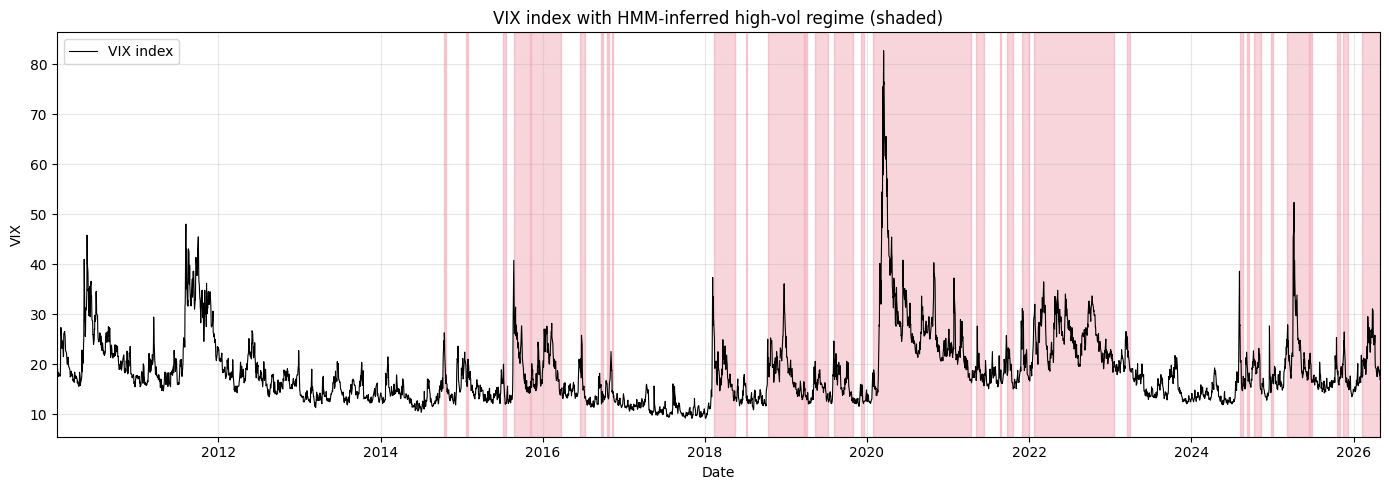

In [4]:
# Forward-fill weekly state to daily for shading (pre-warm rows stay NaN -> unshaded).
daily_state = signals['state_label'].reindex(ny_close, method='ffill')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(vix.index, vix['value'], color='black', linewidth=0.8, label='VIX index')

# Shade contiguous runs of state == 1 (high-vol).
in_high = (daily_state.fillna(0).astype(int) == 1).to_numpy()
diffs = np.diff(in_high.astype(int), prepend=0, append=0)
starts = np.where(diffs == 1)[0]
ends = np.where(diffs == -1)[0]
for s, e in zip(starts, ends):
    ax.axvspan(
        daily_state.index[s],
        daily_state.index[min(e, len(daily_state) - 1)],
        color='crimson', alpha=0.18,
    )

ax.set_title('VIX index with HMM-inferred high-vol regime (shaded)')
ax.set_ylabel('VIX')
ax.set_xlabel('Date')
ax.set_xlim(vix.index.min(), vix.index.max())
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 4. Load 1-minute UXV25 grid

`DataProcessor.process_vx_futures()` returns one `ProcessedContract` per VX ticker, each carrying its 1-min OHLCV bars (and the matching forward-filled BBO panel) on a common UTC master grid. We use the `bars.index` as the broadcast target.

In [5]:
proc = DataProcessor(raw_root=DATA_ROOT)
contracts = proc.process_vx_futures()
print(f'Contracts processed: {sorted(contracts)}')

uxv25 = contracts['UXV25 Index']
minute_grid = uxv25.bars.index
print(f'UXV25 minute grid: {len(minute_grid):,} bars, '
      f'{minute_grid.min()} -> {minute_grid.max()}')
print(f'UXV25 settlement: {uxv25.settlement_date}')

Contracts processed: ['UXF26 Index', 'UXG26 Index', 'UXH26 Index', 'UXJ26 Index', 'UXK26 Index', 'UXV25 Index', 'UXX25 Index', 'UXZ25 Index']
UXV25 minute grid: 283,191 bars, 2025-10-16 21:45:00+00:00 -> 2026-05-01 13:35:00+00:00
UXV25 settlement: 2025-10-22


## 5. Broadcast daily regimes onto the 1-min grid

`broadcast_daily_to_minute` performs a `merge_asof(direction='backward', allow_exact_matches=False)` so that no minute bar can ever observe a daily signal stamped at the same instant. Bars with no prior signal carry NaN (no fabrication).

In [6]:
# Keep all daily signals up to (and slightly past) the end of the minute grid.
# Dropping signals before the grid's start would NaN-out the early minute bars
# that should have inherited the most-recent prior signal.
broadcast_in = signals[signals.index <= minute_grid.max() + pd.Timedelta(days=1)].copy()

minute_signals = broadcast_daily_to_minute(broadcast_in, minute_grid)
print(f'Broadcast output: {minute_signals.shape}')
minute_signals.head()

Broadcast output: (283191, 4)


,state_label,p_state_0,p_state_1,as_of_effective
2025-10-16 21:45:00+00:00,1,0.000003,0.999997,2025-10-16 20:00:00+00:00
2025-10-16 21:46:00+00:00,1,0.000003,0.999997,2025-10-16 20:00:00+00:00
2025-10-16 21:47:00+00:00,1,0.000003,0.999997,2025-10-16 20:00:00+00:00
2025-10-16 21:48:00+00:00,1,0.000003,0.999997,2025-10-16 20:00:00+00:00
2025-10-16 21:49:00+00:00,1,0.000003,0.999997,2025-10-16 20:00:00+00:00


## 6. Strict-shift verification at the NY-close boundary

Pick a daily as_of inside the UXV25 minute window, then print the bars a few minutes either side of the NY-close. Expected pattern:

* Bars **before** the close: `as_of_effective = previous` close.
* The bar **at** the close: still `as_of_effective = previous` (strict — `allow_exact_matches=False`).
* The bar **one minute after** the close: `as_of_effective = current` close. **This is the leak gate.**

If the flip happened on the close minute itself, that would be a same-bar leak; the broadcaster makes that impossible.

In [7]:
# Pick a daily as_of within both the signal range and UXV25's minute range.
in_window = signals.index[(signals.index >= minute_grid.min()) &
                          (signals.index <= minute_grid.max())]
if len(in_window) == 0:
    raise RuntimeError('No daily signal falls inside the UXV25 minute window.')
boundary = in_window[len(in_window) // 2]
print(f'Boundary as_of (NY close, in UTC): {boundary}')

tight = minute_signals.loc[
    boundary - pd.Timedelta(minutes=5) : boundary + pd.Timedelta(minutes=5)
]
print('\nBars around the boundary:')
print('  - rows at or before the boundary timestamp must show the PRIOR signal;')
print('  - the row one minute AFTER the boundary is the first to see the new one.\n')
print(tight[['state_label', 'p_state_0', 'p_state_1', 'as_of_effective']])

Boundary as_of (NY close, in UTC): 2026-01-26 21:00:00+00:00

Bars around the boundary:
  - rows at or before the boundary timestamp must show the PRIOR signal;
  - the row one minute AFTER the boundary is the first to see the new one.

                           state_label  p_state_0  p_state_1  \
2026-01-26 20:55:00+00:00            0   0.935914   0.064086   
2026-01-26 20:56:00+00:00            0   0.935914   0.064086   
2026-01-26 20:57:00+00:00            0   0.935914   0.064086   
2026-01-26 20:58:00+00:00            0   0.935914   0.064086   
2026-01-26 20:59:00+00:00            0   0.935914   0.064086   
2026-01-26 21:00:00+00:00            0   0.935914   0.064086   
2026-01-26 21:01:00+00:00            0   0.994894   0.005106   
2026-01-26 21:02:00+00:00            0   0.994894   0.005106   
2026-01-26 21:03:00+00:00            0   0.994894   0.005106   
2026-01-26 21:04:00+00:00            0   0.994894   0.005106   
2026-01-26 21:05:00+00:00            0   0.994894   0.00510